In [8]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('../week2/Dataset/diabetes_.csv')

df = pd.DataFrame(dataset)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
df.shape

(768, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [16]:
x = df.drop(columns=['Outcome']).values
y = df['Outcome'].values

x

array([[  6.   , 148.   ,  72.   , ...,  33.6  ,   0.627,  50.   ],
       [  1.   ,  85.   ,  66.   , ...,  26.6  ,   0.351,  31.   ],
       [  8.   , 183.   ,  64.   , ...,  23.3  ,   0.672,  32.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,  26.2  ,   0.245,  30.   ],
       [  1.   , 126.   ,  60.   , ...,  30.1  ,   0.349,  47.   ],
       [  1.   ,  93.   ,  70.   , ...,  30.4  ,   0.315,  23.   ]],
      shape=(768, 8))

In [17]:
y

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [21]:
def train_test_split(x, y, test_size =0.3, random_seed = 42 ):

    np.random.seed(random_seed)
    indices = np.arange(x.shape[0])
    test_split_size = int(len(x) * test_size)
    test_indices = indices[:test_split_size]
    train_indices = indices[test_split_size:]
    x_train, x_test = x[train_indices], x[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    return x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

x_train.shape


(538, 8)

In [22]:
x_test.shape


(230, 8)

In [23]:
y_train.shape

(538,)

In [24]:
y_test.shape

(230,)

In [36]:
def euclidean_distance(point1, point2):
    if point1.shape != point2.shape:
        raise ValueError('Must have same dimensions to calculate E distnace')
    distance = np.sqrt(np.sum((point1-point2)**2))
    return distance



In [131]:
try:
    point1 = np.array([3, 4])
    point2 = np.array([0, 0])

    result = euclidean_distance(point1, point2)
    expected_result = 5.0,
    assert np.isclose(result, expected_result), f'Expected {expected_result}, but got{result}'
    print('Test Passed successfully')
except ValueError as ve:
    print(f'ValueError: {ve}')
except AssertionError as ae :
    print(f'AssertionError: {ae}')
except Exception as e:
    print(f'Unexcepted error: {e}')




Test Passed successfully


In [39]:
def knn_predict_single(query, x_train, y_train, k=3):
    distance =[ euclidean_distance(query, x) for x in x_train]
    sorted_indices = np.argsort(distance)
    nearest_indices = sorted_indices[:k]
    nearest_labels = y_train[nearest_indices]
    prediction = np.bincount(nearest_labels).argmax()
    return prediction


In [38]:
def knn_predict(x_test, x_train, y_train, k=3):
    prediction = [knn_predict_single(x, x_train, y_train, k) for x in x_test]
    return np.array(prediction)


In [64]:
try:
    x_test_sample = x_test[:20]
    y_test_sample = y_test[:20]

    predictions = knn_predict(x_test_sample, x_train, y_train, k=3)
    print('Predictions: ', predictions)
    print('Acutal Labels', y_test_sample)
    assert predictions.shape == y_test_sample.shape, 'Doesnot match the shape of actual labels'
    
    # correct = np.sum(y_test_sample == predictions)
    # total = len(y_test_sample)
    # accuracy_sample = (correct/total)*100

    accuracy_samplee = (np.sum(predictions == y_test_sample)/len(y_test_sample))*100
    print(f'Model Accuracy : {accuracy_samplee: .2f}%')
    print(f'Correct Prediction: {np.sum(predictions == y_test_sample)}, out of : {len(y_test_sample)} right answers')
    print('Test passed successfully')
    
except ValueError as ve:
    print(f'ValueError: {ve}')
except AssertionError as ae:
    print(f"AssetionError: {ae}")
except Exception as e:
    print(f'Unaspected Error: {e}')



Predictions:  [1 0 1 0 0 0 0 1 1 0 0 1 1 1 1 0 0 0 0 0]
Acutal Labels [1 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1]
Model Accuracy :  55.00%
Correct Prediction: 11, out of : 20 right answers
Test passed successfully


In [45]:
def compute_accuracy(y_true, y_pred):
    correct_predictions = np.sum(y_true == y_pred)
    total_predictions = len(y_true)
    accuracy = (correct_predictions/total_predictions)*100
    return accuracy


In [74]:
try:
    predictions = knn_predict(x_test, x_train, y_train, k=7)
    accuracy = compute_accuracy(y_test, predictions)
    print(f'Accuract of this Model: {accuracy: .2f}%')
except Exception as e:
    print(f'Unspected Error: {e}')
    

Accuract of this Model:  75.65%


In [128]:
import matplotlib.pyplot as plt
import time

def experiment_k_values(x_train, y_train, x_test, y_test, k_values):

    accuracies = {}
    times = {}
    for k in k_values:
        start_time = time.time()

        predictions = knn_predict(x_test, x_train, y_train, k=k)
        accuracy = compute_accuracy(y_test, predictions)

        end_time = time.time()
        time_taken = end_time - start_time
        
        accuracies[k] = accuracy
        times[k] = time_taken
        print(f'Acuracy for k = {k}: {accuracy: .2f}% | time took: {time_taken: .2f} seconds')
    
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(k_values, list(accuracies.values()), marker='o', color='blue')
    plt.xlabel('k (Number of neighbers)')
    plt.ylabel('Accuarcy %')
    plt.title(' K vs Accuracy %')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(k_values, list(times.values()), marker='o', color='green')
    plt.xlabel('k (Number of neighbers)')
    plt.ylabel('Time took in seconds')
    plt.title(' K vs Time took')
    plt.grid(True)

    plt.tight_layout()
    plt.show()



    best_k = max(accuracies, key=accuracies.get)
    best_accuracy = accuracies[best_k]
    best_time = times[best_k]
    
    return best_k, best_accuracy, accuracies, times, best_time


Acuracy for k = 1:  63.91% | time took:  0.31 seconds
Acuracy for k = 2:  66.96% | time took:  0.30 seconds
Acuracy for k = 3:  70.00% | time took:  0.30 seconds
Acuracy for k = 4:  70.87% | time took:  0.29 seconds
Acuracy for k = 5:  72.17% | time took:  0.29 seconds
Acuracy for k = 6:  72.61% | time took:  0.28 seconds
Acuracy for k = 7:  75.65% | time took:  0.28 seconds
Acuracy for k = 8:  73.48% | time took:  0.31 seconds
Acuracy for k = 9:  73.91% | time took:  0.33 seconds


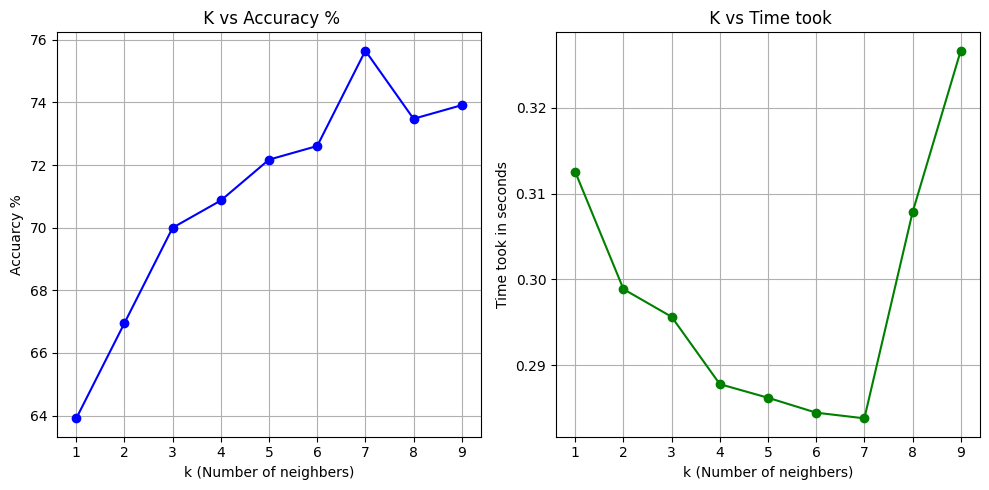

Experiement Completed, Check the plot
Best k : 7
Highest Accuracy:  75.65%
Time took:  0.28 seconds 


In [ ]:
k_values = range(1, 10)

try:
    best_k, best_acc, all_acc, all_times, best_time = experiment_k_values(x_train, y_train, x_test, y_test, k_values)

    print('Experiement Completed, Check the plot')
    print(f'Best k : {best_k}')
    print(f'Highest Accuracy: {best_acc: .2f}%')
    print(f'Time took: {best_time: .2f} seconds ')


except Exception as e:
    print(f'Unspected Error: {e}')


In [135]:
def max_min_scale(x_train):
    return (x_train - x_train.min(axis=0)) / (x_train.max(axis=0) - x_train.min(axis=0) + 1e-8)

x_min = x_train.min(axis=0)
x_max = x_train.max(axis=0)

x_train_scaled = (x_train - x_min)/(x_max - x_min + 1e-8)
x_test_scaled = (x_test - x_min)/(x_max - x_min + 1e-8)


In [143]:

predictions_scaled = knn_predict(x_test_scaled[:20], x_train_scaled, y_train, k=7)
accuracy_scaled = compute_accuracy(predictions_scaled, y_test[:20])

print(f'Scaled Prediction: {predictions_scaled} & Accuracy{accuracy_scaled: .2f}% ')


Scaled Prediction: [0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 0 0 0] & Accuracy 55.00% 


In [186]:
predictions = knn_predict(x_test[:20], x_train, y_train, k=7 )
accuracy = compute_accuracy(predictions, y_test[:20])

print(f'Original data Prediction: {predictions} & Accuracy: {accuracy: .2f}%')

Original data Prediction: [1 0 1 0 1 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0] & Accuracy:  65.00%


In [ ]:

def final_experiment_k_values(
        x_train,
        x_train_scaled,
        x_test,
        x_test_scaled,
        y_train,
        y_test,
        k_values):

    accuracies = {}
    accuracies_s = {}
    times = {}
    times_s = {}

    for k in k_values:

        start = time.time()
        predict = knn_predict(x_test, x_train, y_train, k=k)
        accuracy = compute_accuracy(y_test, predict)
        end = time.time()
        time_taken = end - start
        accuracies[k] = accuracy
        times[k] = time_taken

        start = time.time()
        predict_s = knn_predict(x_test_scaled, x_train_scaled, y_train, k=k)
        accuracy_s = compute_accuracy(y_test, predict_s)
        end = time.time()
        time_taken_s = end-start
        accuracies_s[k] = accuracy_s
        times_s[k] = time_taken_s

        print(f'k = {k} | '
              f'Original: {accuracy:6.2f}% ({time_taken:.3f}s) | '
              f'Scaled: {accuracy_s:6.2f}% ({time_taken_s:.3f}s)')

    
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(k_values, list(accuracies.values()), marker='o', color='red', label='Original')
    plt.plot(k_values, list(accuracies_s.values()), marker='o', color='blue', label='Scaled')
    plt.xlabel('k (Number of neighbers)')
    plt.ylabel('Accuarcy %')
    plt.title(' K vs Accuracy %')
    plt.grid(True)
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(k_values, list(times.values()), marker='o', color="green", label='Original')
    plt.plot(k_values, list(times_s.values()), marker='o', color='orange', label='Scaled' )
    plt.xlabel('k (Number of neighers)')
    plt.ylabel('Time taken')
    plt.title('K vs Time taken')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    best_k_org = max(accuracies, key=accuracies.get)
    best_k_scl = max(accuracies_s, key=accuracies_s.get)
    print(f'Best k (original): {best_k_org} ( {accuracies[best_k_org]: .2f}% )')
    print(f'Best k (scaled): {best_k_scl} ( {accuracies[best_k_scl]: .2f}% )')

    return accuracies, accuracies_s, times, times_s



k = 1 | Original:  63.91% (0.299s) | Scaled:    70.87% (0.288s)
k = 2 | Original:  66.96% (0.286s) | Scaled:    71.30% (0.283s)
k = 3 | Original:  70.00% (0.291s) | Scaled:    72.17% (0.282s)
k = 4 | Original:  70.87% (0.283s) | Scaled:    71.30% (0.287s)
k = 5 | Original:  72.17% (0.294s) | Scaled:    70.00% (0.286s)
k = 6 | Original:  72.61% (0.285s) | Scaled:    71.74% (0.285s)
k = 7 | Original:  75.65% (0.285s) | Scaled:    71.30% (0.283s)
k = 8 | Original:  73.48% (0.286s) | Scaled:    69.57% (0.285s)
k = 9 | Original:  73.91% (0.284s) | Scaled:    71.74% (0.292s)
k = 10 | Original:  73.04% (0.285s) | Scaled:    71.30% (0.284s)
k = 11 | Original:  73.48% (0.285s) | Scaled:    71.30% (0.285s)
k = 12 | Original:  73.91% (0.288s) | Scaled:    71.74% (0.284s)
k = 13 | Original:  74.35% (0.286s) | Scaled:    73.91% (0.286s)
k = 14 | Original:  73.48% (0.286s) | Scaled:    71.74% (0.283s)
k = 15 | Original:  72.17% (0.286s) | Scaled:    73.04% (0.285s)
k = 16 | Original:  73.48% (0.288s

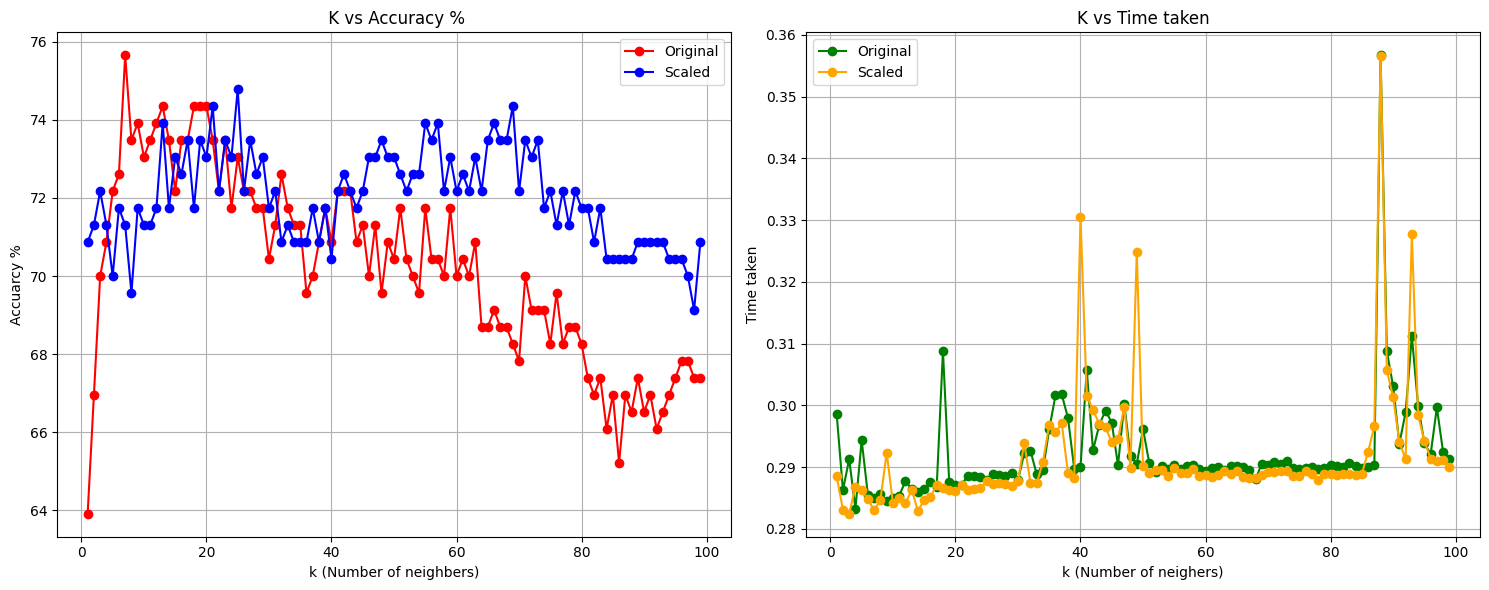

Best k (original): 7 (  75.65% )
Best k (scaled): 25 (  73.04% )
Experiement Successfull, Here is a final plot


In [202]:
k_values = range(1, 100)

try:
    accuracies, accuracies_s, times, times_s = final_experiment_k_values(
        x_train,
        x_train_scaled,
        x_test,
        x_test_scaled,
        y_train,
        y_test,
        k_values)
    print('Experiement Successfull, Here is a final plot')
except Exception as e:
    print(f'Unspected error: {e}')